In [1]:
import scanpy as sc
import torch
import numpy as np
import umap
import matplotlib.pyplot as plt

from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import LabelEncoder


d:\GP\Notebooks\Scimilarity\Scimilarity-venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
import pandas as pd
import scanpy as sc
import anndata as ad

# ---- 1. Load the CSV files ----

# If cell IDs are in the first column:
counts = pd.read_csv(r"D:\GP\Datasets\human_primary_lung_and_bronchial_epithelium_cells\Counts_HBECs.csv", index_col=0)
metadata = pd.read_csv(r"D:\GP\Datasets\human_primary_lung_and_bronchial_epithelium_cells\Metadata_HBECs.csv", index_col=0)

#flip counts
counts = counts.transpose()

# ---- 2. Make sure cells match ----

# Keep only shared cells 
common_cells = counts.index.intersection(metadata.index)

counts = counts.loc[common_cells]
metadata = metadata.loc[common_cells]

# Optional sanity check
print("Counts shape:", counts.shape)
print("Metadata shape:", metadata.shape)

# ---- 3. Create AnnData object ----

adata = ad.AnnData(
    X=counts.values,     # expression matrix
    obs=metadata,        # cell metadata
    var=pd.DataFrame(index=counts.columns)  # gene names
)

# ---- 4. Save as h5ad ----

adata.write(r"D:\GP\Datasets\human_primary_lung_and_bronchial_epithelium_cells\HBECs.h5ad")

print("Saved as HBECs.h5ad")

Counts shape: (17451, 22100)
Metadata shape: (17451, 8)
Saved as HBECs.h5ad


In [3]:
from scimilarity.cell_embedding import CellEmbedding
model_path = r"D:\GP\Scimilarity_test\model\annotation_model_v1"
ce = CellEmbedding(model_path)


In [4]:
adata.layers["counts"] = adata.X.copy()


In [5]:
adata = adata[adata.obs["Cell type"] != "Other"].copy()
print(adata.obs["Cell type"].value_counts())
labels = adata.obs["Cell type"]
X = adata.X
print("Number of classes:", labels.nunique())

Cell type
Club             3347
Secretory2       2871
Ciliated1        2150
Basal1           1923
Basal2           1922
Secretory1       1728
Goblet            980
Ciliated2         614
Basal3            556
Secretory3        474
Fibroblast        377
Basal_Mitotic     305
Ionocyte          124
FOXN4              80
Name: count, dtype: int64
Number of classes: 14


In [6]:
from scimilarity.utils import align_dataset, lognorm_counts
adata = align_dataset(adata, ce.gene_order)
adata = lognorm_counts(adata)


In [7]:
X = adata.X  # sparse or dense is fine

embeddings = ce.get_embeddings(X)
# pass as column in adata
adata.obsm["X_emb"] = embeddings
print(embeddings.shape)


(17451, 128)


In [8]:
# save embeddings to project directory
adata.write_h5ad("D:/GP/Notebooks/Scimilarity/HBECs_embeddings.h5ad")


In [9]:
print(adata.obs['Cell type'])

p46c_AAACCTGAGACCCACC    Secretory3
p46c_AAACCTGAGGACACCA     Ciliated1
p46c_AAACCTGAGTAACCCT        Goblet
p46c_AAACCTGGTCATCGGC        Goblet
p46c_AAACCTGTCACCCGAG     Ciliated2
                            ...    
p51c_TTTGTCACACTGCCAG    Secretory3
p51c_TTTGTCAGTTCACGGC    Secretory2
p51c_TTTGTCATCAACCAAC        Basal1
p51c_TTTGTCATCCTTTCTC        Goblet
p51c_TTTGTCATCTCCGGTT     Ciliated1
Name: Cell type, Length: 17451, dtype: category
Categories (14, object): ['Basal1', 'Basal2', 'Basal3', 'Basal_Mitotic', ..., 'Ionocyte', 'Secretory1', 'Secretory2', 'Secretory3']


In [10]:


from sklearn.model_selection import StratifiedKFold, GridSearchCV, cross_val_predict
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

# logistic regression with cross-validation

clf = LogisticRegression(max_iter=300, solver='lbfgs')

kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
x = adata.obsm["X_emb"]
y = adata.obs["Cell type"] 
y_pred_lr = cross_val_predict(clf, x , y, cv=kf)

# knn with cross-validation
from sklearn.neighbors import KNeighborsClassifier
# knn
# train
knn = KNeighborsClassifier(n_neighbors=15,
    weights="distance",
    metric="cosine")
knn.fit(x, y)
# test
y_pred_knn = cross_val_predict(knn, x , y, cv=kf)



In [11]:
# print y_pred and check classes
print(np.unique(y_pred_lr))
print(np.unique(y_pred_knn))

['Basal1' 'Basal2' 'Basal3' 'Basal_Mitotic' 'Ciliated1' 'Ciliated2' 'Club'
 'FOXN4' 'Fibroblast' 'Goblet' 'Ionocyte' 'Secretory1' 'Secretory2'
 'Secretory3']
['Basal1' 'Basal2' 'Basal3' 'Basal_Mitotic' 'Ciliated1' 'Ciliated2' 'Club'
 'FOXN4' 'Fibroblast' 'Goblet' 'Ionocyte' 'Secretory1' 'Secretory2'
 'Secretory3']


In [12]:
from sklearn.metrics import accuracy_score, classification_report

# Evaluate the model
print("Accuracy (Logistic Regression):", accuracy_score(y, y_pred_lr))
print("Classification Report (Logistic Regression):\n", classification_report(y, y_pred_lr, zero_division=0))

print("Accuracy (k-NN):", accuracy_score(y, y_pred_knn))
print("Classification Report (k-NN):\n", classification_report(y, y_pred_knn))

Accuracy (Logistic Regression): 0.7546845452982637
Classification Report (Logistic Regression):
                precision    recall  f1-score   support

       Basal1       0.74      0.87      0.80      1923
       Basal2       0.74      0.77      0.75      1922
       Basal3       0.71      0.36      0.47       556
Basal_Mitotic       0.96      0.43      0.59       305
    Ciliated1       0.85      0.95      0.90      2150
    Ciliated2       0.89      0.48      0.62       614
         Club       0.70      0.84      0.77      3347
        FOXN4       1.00      0.03      0.05        80
   Fibroblast       0.97      0.98      0.97       377
       Goblet       0.76      0.79      0.77       980
     Ionocyte       0.98      0.85      0.91       124
   Secretory1       0.74      0.72      0.73      1728
   Secretory2       0.71      0.61      0.66      2871
   Secretory3       0.75      0.61      0.67       474

     accuracy                           0.75     17451
    macro avg       0

In [13]:
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay

def plot_cm(y_true, y_pred, title):
    labels = np.unique(y_true)
    cm = confusion_matrix(y_true, y_pred, labels=labels, normalize="true")

    fig, ax = plt.subplots(figsize=(10, 8), dpi=100)

    disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                                  display_labels=labels)

    disp.plot(
        ax=ax,
        cmap="Blues",
        xticks_rotation=90,
        values_format=".2f",
        colorbar=True
    )

    # Make text smaller
    for text in ax.texts:
        text.set_fontsize(7)

    plt.title(title, fontsize=16)
    plt.xlabel("Predicted label", fontsize=12)
    plt.ylabel("True label", fontsize=12)

    plt.tight_layout()
    plt.show()

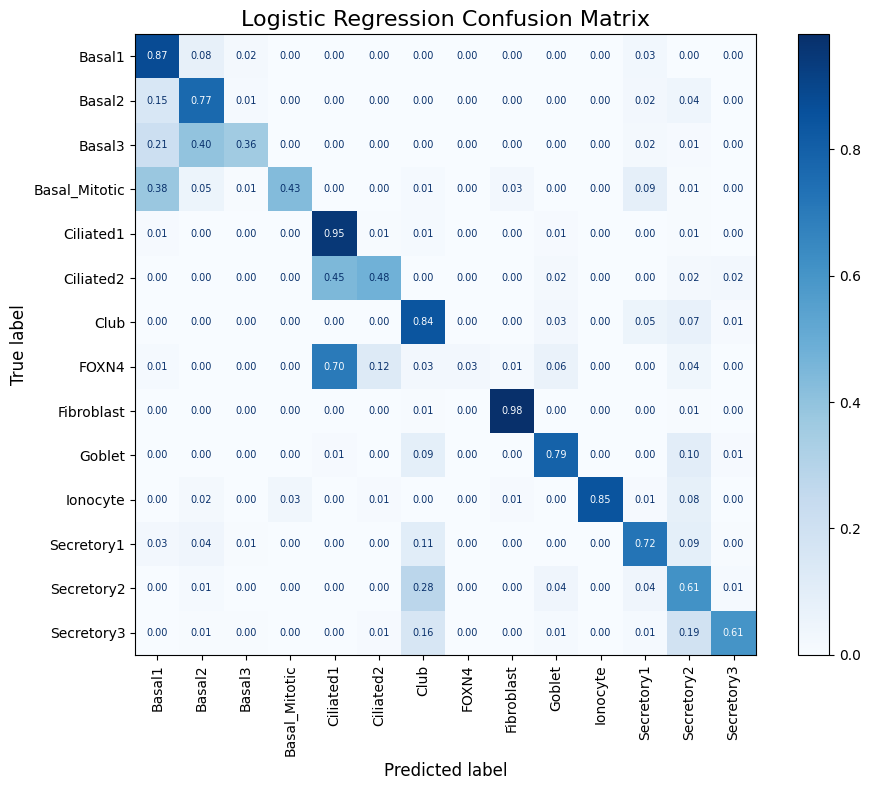

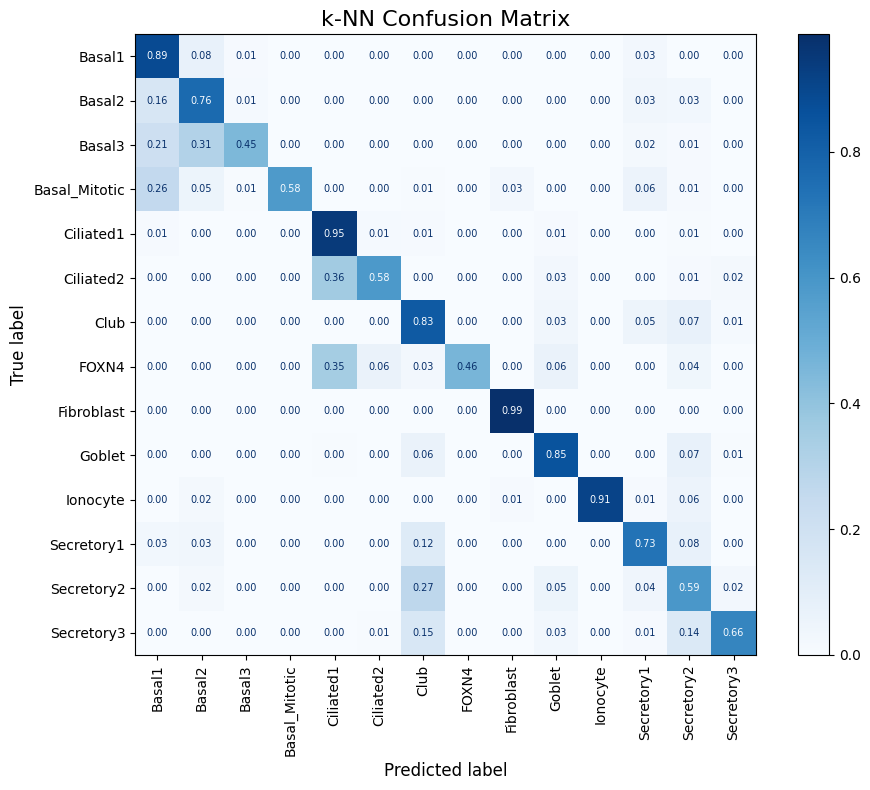

In [14]:
plot_cm(y, y_pred_lr, "Logistic Regression Confusion Matrix")
plot_cm(y, y_pred_knn, "k-NN Confusion Matrix")

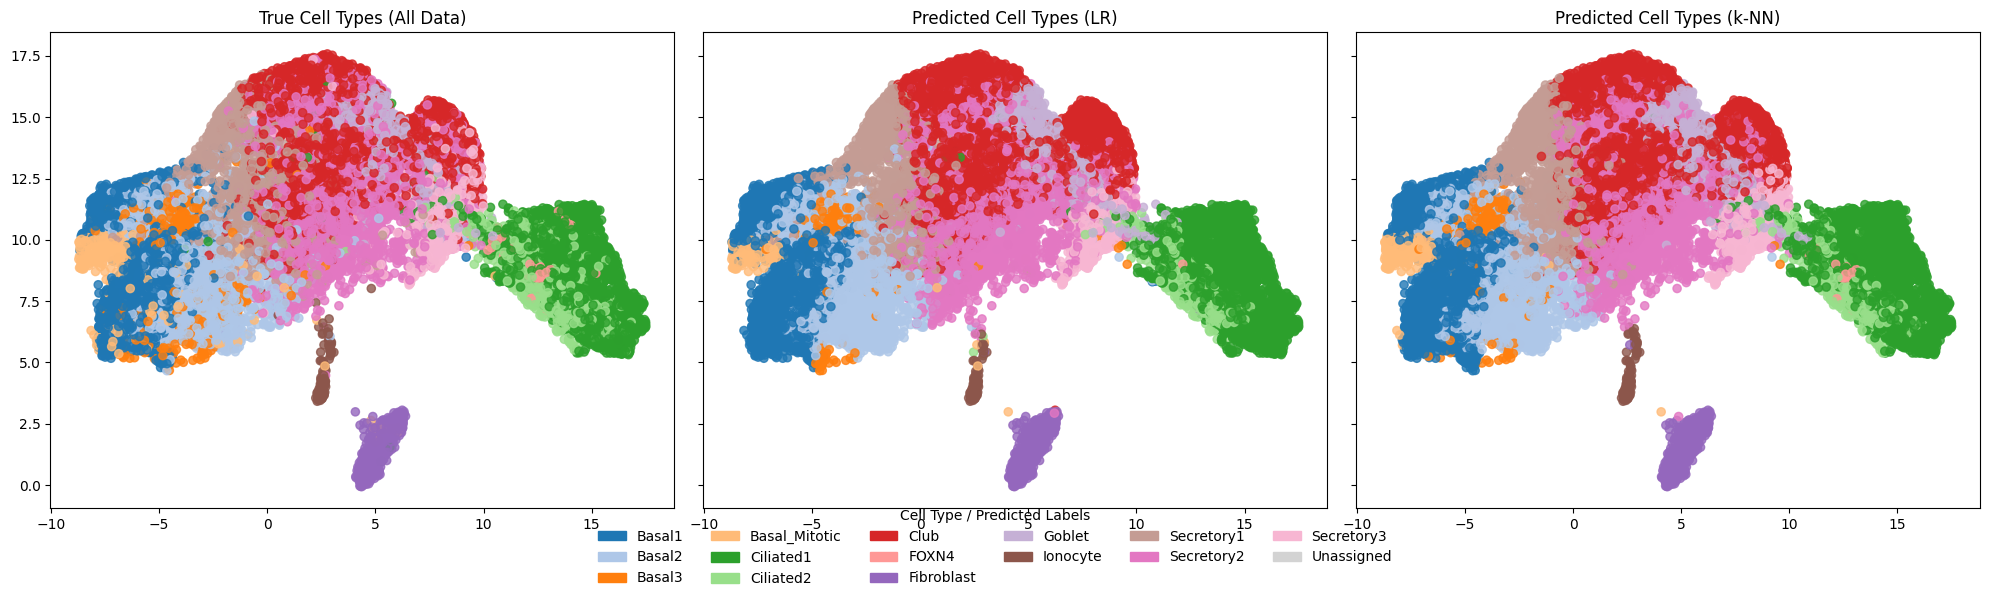

In [15]:
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import pandas as pd

# Fill missing predicted labels
adata.obs['y_pred_lr'] = pd.Series(y_pred_lr, index=adata.obs_names).astype(str).fillna('Unassigned')
adata.obs['y_pred_knn'] = pd.Series(y_pred_knn, index=adata.obs_names).astype(str).fillna('Unassigned')

# PCA + neighbors + UMAP on full data
sc.pp.neighbors(adata, use_rep='X_emb', n_neighbors=15)
sc.tl.umap(adata)

# # Subset predicted cells only
# test_adata = adata[adata.obs['y_pred'] != 'Unassigned'].copy()

# Unified label categories
all_labels = pd.Categorical(pd.concat([
    pd.Series(adata.obs['Cell type'].cat.categories),
    pd.Series(pd.Categorical(adata.obs['y_pred_lr']).categories),
    pd.Series(pd.Categorical(adata.obs['y_pred_knn']).categories)
    
], ignore_index=True)).categories

# Color map
palette = sc.pl.palettes.vega_20
label_to_color = {lbl: palette[i % len(palette)] for i, lbl in enumerate(all_labels)}
label_to_color['Unassigned'] = 'lightgray'

# Add color columns to adata
adata.obs['color_true'] = adata.obs['Cell type'].map(label_to_color)
adata.obs['color_pred_lr'] = adata.obs['y_pred_lr'].map(label_to_color)
adata.obs['color_pred_knn'] = adata.obs['y_pred_knn'].map(label_to_color)
# Plot side by side
fig, axes = plt.subplots(1, 3, figsize=(20, 6), sharex=True, sharey=True)

axes[0].scatter(adata.obsm['X_umap'][:,0], adata.obsm['X_umap'][:,1],
                c=adata.obs['color_true'], s=35, alpha=0.8)
axes[0].set_title('True Cell Types (All Data)')

axes[1].scatter(adata.obsm['X_umap'][:,0], adata.obsm['X_umap'][:,1],
                c=adata.obs['color_pred_lr'], s=35, alpha=0.8)
axes[1].set_title('Predicted Cell Types (LR)')

axes[2].scatter(adata.obsm['X_umap'][:,0], adata.obsm['X_umap'][:,1],
                c=adata.obs['color_pred_knn'], s=35, alpha=0.8)
axes[2].set_title('Predicted Cell Types (k-NN)')

# Shared legend
handles = [Patch(color=color, label=lbl) for lbl, color in label_to_color.items()]
fig.legend(handles=handles, title='Cell Type / Predicted Labels', loc='lower center', ncol=6, frameon=False)



plt.tight_layout(rect=[0, 0.08, 1, 1])
plt.show()
